In [1]:
words = open('data/names.txt', 'r').read().splitlines()

In [ ]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
len(words)

32033

In [ ]:
min(len(w) for w in words), max(len(w) for w in words)

(2, 15)

In [ ]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        # print(ch1, ch2)
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [ ]:
sorted(b.items(), key=lambda x: x[1], reverse=True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [ ]:
import torch

In [ ]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}
stoi['.'] = 0

itos = {i + 1: ch for i, ch in enumerate(chars)}
itos[0] = '.'

In [ ]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

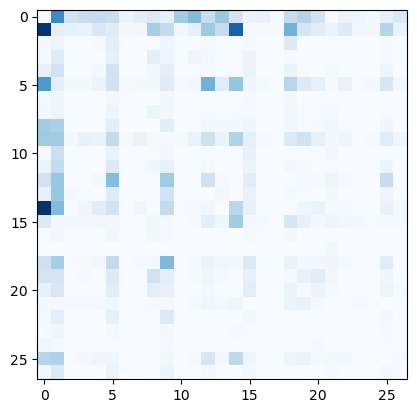

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N.numpy(), cmap='Blues')

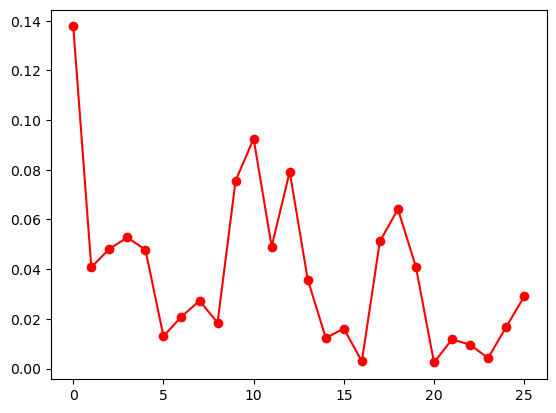

In [ ]:
p = N[0]
p = p / p.sum()
plt.plot(p[1:], 'ro-')

In [ ]:
# model smoothing with 1 as default.
P = (N + 1).float()
P = P / P.sum(1, keepdim=True)

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, 1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))


junide.
janasah.
p.
cony.
a.


In [ ]:
log_likelihood = 0.0
n = 0

for w in words:
# for w in ["nitin"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob.item()
        n += 1
        # print(f'{ch1}{ch2}: {prob:.4f} ({logprob:.4f})')

print(f'log likelihood: {log_likelihood:.4f}')
nll = -log_likelihood
print(f'nll: {nll:.4f}')
print(f'{nll/n}')

log likelihood: -560001.8843
nll: 560001.8843
2.4545768249521656


In [ ]:
# Create a training set with the bigrams and their counts
# input is first character, output is second character
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
xs, ys

. e
e m
m m
m a
a .


(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

In [ ]:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).reshape(-1, 27).float()
print(xenc.shape, xenc.dtype)

W = torch.randn(27, 27, requires_grad=True, generator=g)
b = torch.randn(27, requires_grad=True, generator=g)
print(W.shape, b.shape)

out = xenc @ W

# verification of the output
print(out[3, 13])
(xenc[3,:] * W[:,13]).sum()

probs = out.exp() / out.exp().sum(1, keepdim=True)
probs, probs.shape

torch.Size([5, 27]) torch.float32
torch.Size([27, 27]) torch.Size([27])
tensor(0.9322, grad_fn=<SelectBackward0>)


(tensor([[0.0025, 0.0104, 0.0172, 0.0109, 0.1280, 0.0237, 0.0078, 0.0133, 0.2163,
          0.0142, 0.0424, 0.0720, 0.0087, 0.0094, 0.0099, 0.0177, 0.1043, 0.0549,
          0.0111, 0.0079, 0.0527, 0.0139, 0.0089, 0.0261, 0.0472, 0.0018, 0.0667],
         [0.0849, 0.0066, 0.0191, 0.0146, 0.0466, 0.0184, 0.0324, 0.1156, 0.0838,
          0.0085, 0.1664, 0.0272, 0.0150, 0.0158, 0.0092, 0.0021, 0.0096, 0.0465,
          0.0211, 0.0123, 0.0358, 0.0151, 0.0103, 0.0094, 0.1440, 0.0061, 0.0237],
         [0.0245, 0.0170, 0.0217, 0.0324, 0.0273, 0.0248, 0.0108, 0.0138, 0.0053,
          0.0657, 0.2264, 0.0109, 0.1082, 0.0693, 0.0393, 0.0492, 0.0091, 0.0091,
          0.0055, 0.0124, 0.0232, 0.0804, 0.0199, 0.0144, 0.0286, 0.0400, 0.0108],
         [0.0245, 0.0170, 0.0217, 0.0324, 0.0273, 0.0248, 0.0108, 0.0138, 0.0053,
          0.0657, 0.2264, 0.0109, 0.1082, 0.0693, 0.0393, 0.0492, 0.0091, 0.0091,
          0.0055, 0.0124, 0.0232, 0.0804, 0.0199, 0.0144, 0.0286, 0.0400, 0.0108],
         [0.

In [ ]:
nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item()
    y = ys[i].item()
    print("------------------------")
    print(f"bigram example {i + 1}: {itos[x]}{itos[y]} (index {x}{y})")
    print(f"Input to neural net: {x}")
    print(f"Output probabilities: {probs[i]}")
    print(f"label (actual next character): {itos[y]}")
    
    p = probs[i, y]
    print(f"Probablity assigned by neural net to actual character: {p:.4f}")
    print(f"label assigned by neural net: {itos[probs[i].argmax().item()]}")
    
    logp = torch.log(p).item()
    nll = -logp
    print(f"Negative log likelihood: {nll:.4f}")
    nlls[i] = nll

print(f"===========================")
print(f"Average negative log likelihood: {nlls.mean():.4f}")



------------------------
bigram example 1: .e (index 05)
Input to neural net: 0
Output probabilities: tensor([0.0025, 0.0104, 0.0172, 0.0109, 0.1280, 0.0237, 0.0078, 0.0133, 0.2163,
        0.0142, 0.0424, 0.0720, 0.0087, 0.0094, 0.0099, 0.0177, 0.1043, 0.0549,
        0.0111, 0.0079, 0.0527, 0.0139, 0.0089, 0.0261, 0.0472, 0.0018, 0.0667],
       grad_fn=<SelectBackward0>)
label (actual next character): e
Probablity assigned by neural net to actual character: 0.0237
label assigned by neural net: h
Negative log likelihood: 3.7430
------------------------
bigram example 2: em (index 513)
Input to neural net: 5
Output probabilities: tensor([0.0849, 0.0066, 0.0191, 0.0146, 0.0466, 0.0184, 0.0324, 0.1156, 0.0838,
        0.0085, 0.1664, 0.0272, 0.0150, 0.0158, 0.0092, 0.0021, 0.0096, 0.0465,
        0.0211, 0.0123, 0.0358, 0.0151, 0.0103, 0.0094, 0.1440, 0.0061, 0.0237],
       grad_fn=<SelectBackward0>)
label (actual next character): m
Probablity assigned by neural net to actual character

In [ ]:
# Foward pass.
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).reshape(-1, 27).float()
W = torch.randn(27, 27, requires_grad=True, generator=g)
out = xenc @ W

probs = out.exp() / out.exp().sum(1, keepdim=True)
loss = -probs[torch.arange(len(xs)), ys].log().mean()
loss

tensor(3.9796, grad_fn=<NegBackward0>)

In [ ]:
print(loss.item())

3.9796271324157715


In [ ]:
# Backward pass.
W.grad = None
loss.backward()

In [ ]:
W.data += -0.1 * W.grad

In [ ]:
print(loss.item())

3.9796271324157715


FRESH e2e Gradient based approach


In [ ]:
n = 0
xs = []
ys = []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
        n += 1
print(f"Number of bigrams: {n}")
xs = torch.tensor(xs)
ys = torch.tensor(ys)

# Init network
g = torch.Generator().manual_seed(2147483647)
W = torch.randn(27, 27, requires_grad=True, generator=g)
b = torch.randn(27, requires_grad=True, generator=g)

Number of bigrams: 228146


Iteration 0: loss = 4.1545


Iteration 10: loss = 2.7283
Iteration 20: loss = 2.5979
Iteration 30: loss = 2.5519
Iteration 40: loss = 2.5283


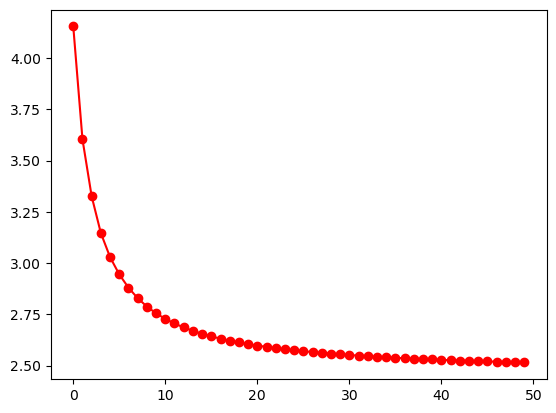

In [ ]:
losses = []
for k in range(50):
    # Forward pass.
    xenc = F.one_hot(xs, num_classes=27).reshape(-1, 27).float()
    out = xenc @ W + b
    probs = out.exp() / out.exp().sum(1, keepdim=True)
    loss = -probs[torch.arange(len(xs)), ys].log().mean() + 0.01 * ((W ** 2).mean())
    losses.append(loss.item())
    if k % 10 == 0:
        # Print every 10 iterations.
        print(f"Iteration {k}: loss = {loss.item():.4f}")

    # Backward pass.
    W.grad = None
    b.grad = None
    loss.backward()

    # Update weights.
    W.data += -40 * W.grad
    b.data += -1 * b.grad

plt.plot(losses, 'ro-')

In [ ]:
g = torch.Generator().manual_seed(2147483647)
for i in range(5):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).reshape(-1, 27).float()
        logits = xenc @ W + b
        probs = logits.exp() / logits.exp().sum(1, keepdim=True)
        ix = torch.multinomial(probs, 1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

juwide.
janasah.
pfelay.
a.
nn.
